In [2]:
pwd

'/Users/bhianca/SN_infrared_classification/training'

In [ ]:
from __future__ import annotations

import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch

# ── Bundle de datos (único path que cambia al mover de máquina) ──────────────
# Contiene: sn/hourglass_{objects,photometry}.parquet  y  kn/kn_grid_v1/
DATA_ROOT   = Path("/Volumes/Elements/kn_sn_bundle")      # ← editar al mover
SN_DIR      = DATA_ROOT / "sn"
KN_GRID_DIR = DATA_ROOT / "kn" / "kn_grid_v1"

# ── Código del repo (paths relativos al notebook) ────────────────────────────
REPO_ROOT     = Path.cwd().parent           # notebook en training/
FUNCIONES_DIR = REPO_ROOT / "data" / "sn" / "hourglass_snana_zenodo"
KN_CODE_DIR   = REPO_ROOT / "data" / "kn"

sys.path.insert(0, str(FUNCIONES_DIR))
sys.path.insert(0, str(KN_CODE_DIR))

from funciones import (  # noqa: E402
    build_split_loaders,
    LightCurveEncoder,
    nt_xent_loss,
    ALL_BANDS,
)

# ── Config de entrenamiento ──────────────────────────────────────────────────
SNANA_SENTINEL = 60.0     # SNANA: sim_mag_obs=60 → no-simulación

BATCH_SIZE   = 32
NUM_WORKERS  = 4
SEED         = 42

assert DATA_ROOT.exists(),    f"Bundle no encontrado: {DATA_ROOT}"
assert SN_DIR.exists(),       f"SN dir no encontrado: {SN_DIR}"
assert KN_GRID_DIR.exists(),  f"KN grid no encontrada: {KN_GRID_DIR}"
print(f"Bundle OK: {DATA_ROOT}")

In [ ]:
# ── Preparar datos SN ────────────────────────────────────────────────────────
def load_sn_data() -> tuple[pd.DataFrame, pd.DataFrame]:
    """Carga y preprocesa la fotometría SN del survey Hourglass."""
    objects_raw = pd.read_parquet(SN_DIR / "hourglass_objects.parquet").set_index("cid")
    phot_raw    = pd.read_parquet(SN_DIR / "hourglass_photometry.parquet")

    # fluxcal → mag AB (ZP=27.5)
    phot_raw["mag"]     = 27.5 - 2.5 * np.log10(phot_raw["fluxcal"].clip(lower=1e-30))
    phot_raw["mag_err"] = (2.5 / np.log(10)) * (
        phot_raw["fluxcal_err"] / phot_raw["fluxcal"]
    ).clip(0, 2)

    # Filtrar: bandas Roman, detecciones reales, fluxcal > 0
    mask = (
        phot_raw["band"].isin(ALL_BANDS)
        & (phot_raw["fluxcal"] > 0)
        & (phot_raw["sim_mag_obs"] != SNANA_SENTINEL)
    )
    df = phot_raw.loc[mask].copy()

    return df, objects_raw


# Datos
print("Cargando fotometría SN...")
df, objects_raw = load_sn_data()
print(f"  {len(df)} observaciones, {df['cid'].nunique()} objetos")

# Survey MJDs
survey_mjds = {
    b: np.sort(df.loc[df["band"] == b, "mjd"].unique())
    for b in ALL_BANDS
}
for b in ALL_BANDS:
    print(f"  {b}: {len(survey_mjds[b])} MJDs únicos")

# Splits
print("Construyendo splits train/val/test...")
splits = build_split_loaders(
    sn_df=df,
    sn_objects=objects_raw,
    survey_mjds=survey_mjds,
    kn_grid_dir=str(KN_GRID_DIR),
    kn_n_virtual=(80_000, 10_000, 10_000),
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    seed=SEED,
)

train_loader = splits["train"]["loader"]
val_loader   = splits["val"]["loader"]

In [3]:
  quick_loader = torch.utils.data.DataLoader(                                   
      train_loader.dataset,                                                     
      batch_size=4,                                                             
      shuffle=True,                                                             
      collate_fn=train_loader.collate_fn,                                       
      num_workers=0,          # sin multiprocessing                             
  )                                                                             
                                                                                
  x1, x2, m1, m2, z, labels = next(iter(quick_loader))                          
   
  print(f"x1: {x1.shape}  x2: {x2.shape}")                                      
  print(f"m1: {m1.shape}  m2: {m2.shape}")                                    
  print(f"z:  {z.shape}   labels: {labels}") 
                                                                            
                                                                            

x1: torch.Size([4, 6, 25])  x2: torch.Size([4, 6, 25])
m1: torch.Size([4, 6])  m2: torch.Size([4, 6])
z:  torch.Size([4])   labels: tensor([1, 0, 0, 0])


In [43]:
ds_sn = splits["train"]["ds_sn"]                                              

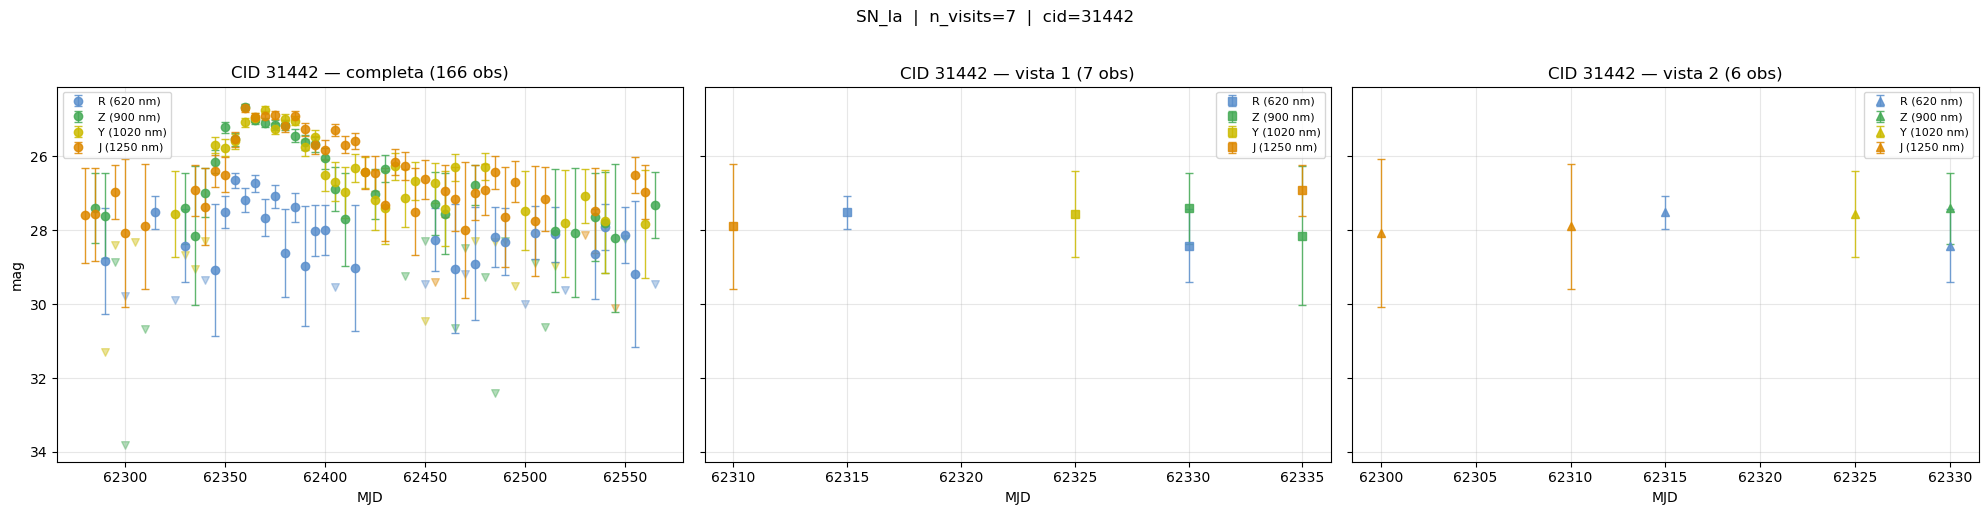

In [74]:
ds_sn.plot()

In [ ]:
# ── Modelo, optimizer, scheduler ─────────────────────────────────────────────
EPOCHS       = 50
LR           = 3e-4
WEIGHT_DECAY = 1e-4
PROBE_EVERY  = 5

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"
print(f"Device: {device}")

model = LightCurveEncoder(bands=ALL_BANDS).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Modelo: {n_params:,} parámetros entrenables")

In [ ]:
# ── Linear probe: métrica real de calidad del encoder ───────────────────────
# La val loss NT-Xent no es comparable entre batches/configs. Usamos linear
# probe sobre CLS bruto para medir separación de clases real.

@torch.no_grad()
def extract_embeddings(model, loader, device):
    model.eval()
    embs, labels_list = [], []
    for x1, x2, m1, m2, z, labels in loader:
        x1, m1, z = x1.to(device), m1.to(device), z.to(device)
        cls = model.encode(x1, m1, z)
        embs.append(cls.cpu())
        labels_list.append(labels)
    return torch.cat(embs), torch.cat(labels_list)


def linear_probe(model, train_loader, val_loader, device, n_classes=2):
    Xtr, ytr = extract_embeddings(model, train_loader, device)
    Xva, yva = extract_embeddings(model, val_loader, device)

    clf = torch.nn.Linear(Xtr.shape[1], n_classes).to(device)
    opt = torch.optim.AdamW(clf.parameters(), lr=1e-3, weight_decay=1e-4)
    Xtr_d, ytr_d = Xtr.to(device), ytr.to(device)

    for _ in range(200):
        opt.zero_grad()
        loss = torch.nn.functional.cross_entropy(clf(Xtr_d), ytr_d)
        loss.backward()
        opt.step()

    with torch.no_grad():
        pred = clf(Xva.to(device)).argmax(-1).cpu()
    return (pred == yva).float().mean().item()

In [ ]:
# ── Training loop ────────────────────────────────────────────────────────────
CHECKPOINT_DIR = REPO_ROOT / "training" / "checkpoints"
CHECKPOINT_DIR.mkdir(exist_ok=True)

best_probe_acc = 0.0

for epoch in range(EPOCHS):
    model.train()
    total_loss, n_batches = 0.0, 0
    t0 = time.time()

    for x1, x2, m1, m2, z, labels in train_loader:
        x1, x2 = x1.to(device), x2.to(device)
        m1, m2 = m1.to(device), m2.to(device)
        z      = z.to(device)

        h1, h2 = model(x1, m1, x2, m2, z)
        loss = nt_xent_loss(h1, h2)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        n_batches += 1

    scheduler.step()
    avg_loss = total_loss / max(n_batches, 1)
    elapsed  = time.time() - t0
    lr_now   = scheduler.get_last_lr()[0]

    print(f"Epoch {epoch:3d}  loss={avg_loss:.4f}  lr={lr_now:.2e}  "
          f"({elapsed:.0f}s, {n_batches} batches)")

    # Linear probe + checkpoint del mejor encoder
    if (epoch + 1) % PROBE_EVERY == 0 or epoch == EPOCHS - 1:
        acc = linear_probe(model, train_loader, val_loader, device)
        print(f"  >> linear probe acc = {acc:.3f}")

        if acc > best_probe_acc:
            best_probe_acc = acc
            ckpt_path = CHECKPOINT_DIR / "best_encoder.pt"
            torch.save({
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "probe_acc": acc,
                "loss": avg_loss,
            }, ckpt_path)
            print(f"  >> saved checkpoint (acc={acc:.3f}) → {ckpt_path}")

        model.train()

print(f"\nDone. Best linear probe acc = {best_probe_acc:.3f}")